## Aggregate Year-over-Year Changes for 1979-2024

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [66]:
# ============================================================================
# CONFIGURATION: Modern Period Analysis (1979-2024)
# ============================================================================

START_YEAR = 1979
END_YEAR = 2025


print(f"{'='*80}")
print(f"HISTORICAL PERIOD ANALYSIS: {START_YEAR}-{END_YEAR}")
print(f"Using AVERAGE for aggregate calculations")
print(f"{'='*80}\n")

HISTORICAL PERIOD ANALYSIS: 1979-2025
Using AVERAGE for aggregate calculations



In [67]:
# Load your data
df_raw = pd.read_csv('/Users/namithageorge/msai339/project/National-Parks-DS/Datasets/national_parks_cleaned.csv')
print(df_raw['Year'].min())
print(df_raw['Year'].max())

print("Data shape:", df_raw.shape)
print("\nFirst few rows:")
print(df_raw.head())

# Aggregate monthly data to annual totals
# Group by ParkName and Year, then sum RecreationVisits
df_annual = df_raw.groupby(['ParkName', 'Year'])['RecreationVisits'].sum().reset_index()

print("\nAnnual aggregated data shape:", df_annual.shape)
print("\nAnnual data sample:")
print(df_annual.head(10))


# pivot: parks as rows, years as columns, annual recreation visits as values
df_pivot = df_annual.pivot(index='ParkName', columns='Year', values='RecreationVisits')

print("\nPivoted data shape:", df_pivot.shape)
print("\nPivoted data (first few rows and columns):")
print(df_pivot.iloc[:5, :10] if df_pivot.shape[1] >= 10 else df_pivot.iloc[:5])

# Sort columns (years) to ensure proper ordering
df = df_pivot.sort_index(axis=1)

# Convert all values to numeric 
df = df.apply(pd.to_numeric, errors='coerce')

print("\nFinal data ready for analysis!")
print(f"Parks: {len(df)}, Years: {len(df.columns)}")

1979
2025
Data shape: (34643, 18)

First few rows:
    ParkName UnitCode       ParkType     Region State  Year     Month  \
0  Acadia NP     ACAD  National Park  Northeast    ME  1979   January   
1  Acadia NP     ACAD  National Park  Northeast    ME  1979  February   
2  Acadia NP     ACAD  National Park  Northeast    ME  1979     March   
3  Acadia NP     ACAD  National Park  Northeast    ME  1979     April   
4  Acadia NP     ACAD  National Park  Northeast    ME  1979       May   

   RecreationVisits  NonRecreationVisits  RecreationHours  NonRecreationHours  \
0            6011.0              15252.0          37446.0             15252.0   
1            5243.0              13776.0          17661.0             13776.0   
2           11165.0              15252.0          36051.0             15252.0   
3          219351.0              37657.0        1334058.0             37657.0   
4          339416.0              50616.0        2088588.0             50616.0   

   ConcessionerLodging 

In [68]:
# ============================================================================
# CONFIGURATION: Exclude Specific Years and Set Thresholds
# ============================================================================

# Set to True to exclude COVID years, False to include all years
EXCLUDE_COVID_YEARS = True  # Toggle this to True/False

# Specify which years to exclude
YEARS_TO_EXCLUDE = [2020, 2021, 2025]  # Modify this list as needed

# Z-score threshold for outlier detection
Z_SCORE_THRESHOLD = 1  # Change to adjust sensitivity

# Modified z-score threshold
MODIFIED_Z_THRESHOLD = 2.5  # Change for modified z-score method

if EXCLUDE_COVID_YEARS:
    print(f"\n{'='*80}")
    print(f"EXCLUDING YEARS: {YEARS_TO_EXCLUDE}")
    print(f"{'='*80}\n")
    
    # Remove specified years from the dataframe
    df = df.drop(columns=YEARS_TO_EXCLUDE, errors='ignore')
    print(f"Remaining years: {list(df.columns)}")
    print(f"Total years in analysis: {len(df.columns)}")
else:
    print(f"\n{'='*80}")
    print(f"ANALYZING ALL YEARS (no exclusions)")
    print(f"{'='*80}\n")

print(f"\nZ-Score Threshold: ±{Z_SCORE_THRESHOLD} SD")
print(f"Modified Z-Score Threshold: ±{MODIFIED_Z_THRESHOLD}")
print("="*80)


EXCLUDING YEARS: [2020, 2021, 2025]

Remaining years: [1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2022, 2023, 2024]
Total years in analysis: 44

Z-Score Threshold: ±1 SD
Modified Z-Score Threshold: ±2.5


In [69]:
# ============================================================================
# STEP 1: Calculate Year-over-Year Changes
# ============================================================================

# Calculate absolute differences
yoy_changes = df.diff(axis=1)

print("\n" + "="*80)
print("YEAR-OVER-YEAR CHANGES")
print("="*80)
print(yoy_changes.head())


YEAR-OVER-YEAR CHANGES
Year         1979      1980      1981      1982      1983      1984      1985  \
ParkName                                                                        
Acadia NP     NaN   -7700.0  218306.0  574142.0  552525.0 -389876.0   10807.0   
Arches NP     NaN   20679.0   35989.0   12907.0  -51540.0   57305.0   18284.0   
Badlands NP   NaN   94652.0  223300.0 -145468.0   -3503.0   86694.0 -163433.0   
Big Bend NP   NaN -108933.0   -6676.0   12812.0  -15218.0    2739.0   20380.0   
Biscayne NP   NaN   45133.0   57431.0   42717.0   20863.0  -28515.0  120354.0   

Year             1986      1987      1988  ...      2013      2014      2015  \
ParkName                                   ...                                 
Acadia NP    183484.0  359100.0  214129.0  ... -176130.0  308207.0  248055.0   
Arches NP     55980.0   49472.0   51539.0  ...   12289.0  201901.0  114480.0   
Badlands NP   75388.0  148768.0  -64358.0  ...    8966.0  -24278.0  121260.0   
Big Bend

In [70]:
# ============================================================================
# STEP 2: OUTLIER DETECTION
# ============================================================================

# Method 1: Z-Score for Each Park-Year Combination
print("\n" + "="*80)
print("METHOD 1: Z-SCORE OUTLIER DETECTION")
print("="*80)

z_scores = pd.DataFrame(index=yoy_changes.index, columns=yoy_changes.columns)

for park in yoy_changes.index:
    park_changes = yoy_changes.loc[park].dropna()
    mean_change = park_changes.mean()
    std_change = park_changes.std()
    
    if std_change > 0:  # Avoid division by zero
        z_scores.loc[park] = (yoy_changes.loc[park] - mean_change) / std_change

# Flag outliers
outliers_z = z_scores.abs() > Z_SCORE_THRESHOLD

print(f"\nOutliers by Z-Score (|z| > {Z_SCORE_THRESHOLD}):")
print(outliers_z.sum(axis=0))  # Count outliers per year

# Method 2: Modified Z-Score (More Robust)
print("\n" + "="*80)
print("METHOD 2: MODIFIED Z-SCORE (ROBUST)")
print("="*80)

modified_z_scores = pd.DataFrame(index=yoy_changes.index, columns=yoy_changes.columns)

for park in yoy_changes.index:
    park_changes = yoy_changes.loc[park].dropna()
    median_change = park_changes.median()
    mad = np.median(np.abs(park_changes - median_change))
    
    if mad > 0:  # No division by zero
        modified_z_scores.loc[park] = 0.6745 * (yoy_changes.loc[park] - median_change) / mad

# Flag outliers (using configurable threshold)
outliers_modified_z = modified_z_scores.abs() > MODIFIED_Z_THRESHOLD

print(f"\nOutliers by Modified Z-Score (|z| > {MODIFIED_Z_THRESHOLD}):")
print(outliers_modified_z.sum(axis=0))  # Count outliers per year

# Method 3: Aggregate Year-Level Detection
print("\n" + "="*80)
print("METHOD 3: AGGREGATE YEAR-LEVEL OUTLIERS")
print("="*80)

# Sum changes across all parks for each year
aggregate_changes = yoy_changes.mean(axis=0)

# Calculate z-scores for aggregate changes
agg_mean = aggregate_changes.mean()
agg_std = aggregate_changes.std()
aggregate_z_scores = (aggregate_changes - agg_mean) / agg_std

print("\nAggregate Z-Scores by Year:")
print(aggregate_z_scores.sort_values())

# Flag years with |z-score| > threshold
outlier_years = aggregate_z_scores[aggregate_z_scores.abs() > Z_SCORE_THRESHOLD]
print(f"\nOutlier Years (|z| > {Z_SCORE_THRESHOLD}): {list(outlier_years.index)}")

# Method 4: Count Parks with Outliers per Year
print("\n" + "="*80)
print("METHOD 4: SYSTEM-WIDE OUTLIER DETECTION")
print("="*80)

parks_with_outliers = outliers_z.sum(axis=0)
print("\nNumber of Parks with Outliers Each Year:")
print(parks_with_outliers.sort_values(ascending=False))


METHOD 1: Z-SCORE OUTLIER DETECTION

Outliers by Z-Score (|z| > 1):
Year
1979     0
1980    10
1981    14
1982    12
1983    11
1984    10
1985    13
1986     7
1987     9
1988    10
1989     9
1990     7
1991    12
1992    15
1993    14
1994    13
1995    13
1996    15
1997    10
1998    15
1999    12
2000    17
2001    11
2002    11
2003    11
2004     9
2005     8
2006    12
2007     6
2008    10
2009    13
2010     7
2011    19
2012    15
2013    11
2014    16
2015    21
2016    27
2017    23
2018    20
2019    15
2022    33
2023    21
2024    17
dtype: int64

METHOD 2: MODIFIED Z-SCORE (ROBUST)

Outliers by Modified Z-Score (|z| > 2.5):
Year
1979     0
1980     5
1981     3
1982     5
1983     3
1984     4
1985     3
1986     3
1987     4
1988     4
1989     3
1990     5
1991     6
1992     5
1993     6
1994     5
1995     6
1996     9
1997     2
1998     7
1999     6
2000     8
2001     2
2002     1
2003     2
2004     5
2005     3
2006     4
2007     0
2008     2
2009     4
201

/opt/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


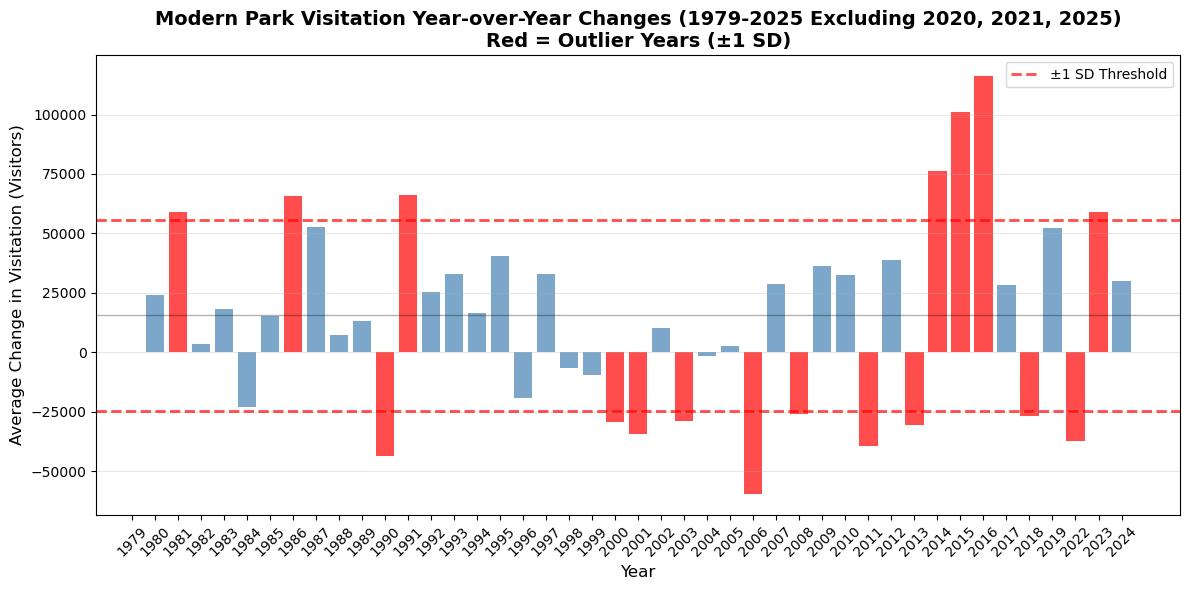

In [71]:
# ============================================================================
# STEP 3: Visualization of Aggregate Outliers
# ============================================================================

# Bar chart of aggregate changes with outlier threshold
plt.figure(figsize=(12, 6))
colors = ['red' if abs(z) > Z_SCORE_THRESHOLD else 'steelblue' for z in aggregate_z_scores]
plt.bar(aggregate_changes.index.astype(str), aggregate_changes.values, color=colors, alpha=0.7)
plt.axhline(y=agg_mean + Z_SCORE_THRESHOLD*agg_std, color='red', linestyle='--', 
            linewidth=2, label=f'±{Z_SCORE_THRESHOLD} SD Threshold', alpha=0.7)
plt.axhline(y=agg_mean - Z_SCORE_THRESHOLD*agg_std, color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.axhline(y=agg_mean, color='black', linestyle='-', linewidth=1, alpha=0.3)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Change in Visitation (Visitors)', fontsize=12)

# Add title based on whether years are excluded
if EXCLUDE_COVID_YEARS:
    title = f'Modern Park Visitation Year-over-Year Changes (1979-2025 Excluding {", ".join(map(str, YEARS_TO_EXCLUDE))})\nRed = Outlier Years (±{Z_SCORE_THRESHOLD} SD)'
else:
    title = f'Modern Park Visitation Year-over-Year Changes\nRed = Outlier Years (±{Z_SCORE_THRESHOLD} SD)'
    
plt.title(title, fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

# Save with different filename based on exclusion
filename = 'aggregate_outliers_excl.png' if EXCLUDE_COVID_YEARS else 'aggregate_outliers.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()


In [72]:
# ============================================================================
# STEP 4: Summary Report
# ============================================================================

print("\n" + "="*80)
print("SUMMARY REPORT")
print("="*80)

if EXCLUDE_COVID_YEARS:
    print(f"\n*** ANALYSIS EXCLUDES: {', '.join(map(str, YEARS_TO_EXCLUDE))} ***")

print(f"\nTotal Parks Analyzed: {len(df)}")
print(f"Time Period: {START_YEAR} to {END_YEAR}")
print(f"Total Years: {len(df.columns)}")

print(f"\n--- Outlier Detection Results ---")
print(f"Years identified as system-wide outliers: {list(outlier_years.index)}")
if len(outlier_years) > 0:
    print(f"Year with most park-level outliers: {parks_with_outliers.idxmax()} ({parks_with_outliers.max()} parks)")

# Identify parks with most outliers
park_outlier_counts = outliers_z.sum(axis=1)
print(f"\nParks with most outliers:")
print(park_outlier_counts.sort_values(ascending=False).head())

# Export results to CSV
results_df = pd.DataFrame({
    'Year': aggregate_changes.index,
    'Aggregate_Change': aggregate_changes.values,
    'Z_Score': aggregate_z_scores.values,
    'Is_Outlier': aggregate_z_scores.abs() > Z_SCORE_THRESHOLD,
    'Parks_With_Outliers': parks_with_outliers.values
})

# Save with different filename based on exclusion
csv_filename = 'outlier_analysis_results_excl.csv' if EXCLUDE_COVID_YEARS else 'outlier_analysis_results.csv'
results_df.to_csv(csv_filename, index=False)
print(f"\nResults exported to '{csv_filename}'")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)


SUMMARY REPORT

*** ANALYSIS EXCLUDES: 2020, 2021, 2025 ***

Total Parks Analyzed: 64
Time Period: 1979 to 2025
Total Years: 44

--- Outlier Detection Results ---
Years identified as system-wide outliers: [1981, 1986, 1990, 1991, 2000, 2001, 2003, 2006, 2008, 2011, 2013, 2014, 2015, 2016, 2018, 2022, 2023]
Year with most park-level outliers: 2022 (33 parks)

Parks with most outliers:
ParkName
Shenandoah NP          17
Mount Rainier NP       15
Carlsbad Caverns NP    14
Gateway Arch NP        14
Virgin Islands NP      14
dtype: int64

Results exported to 'outlier_analysis_results_excl.csv'

ANALYSIS COMPLETE
